In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fifa-20-complete-player-dataset/players_15.csv
/kaggle/input/fifa-20-complete-player-dataset/players_16.csv
/kaggle/input/fifa-20-complete-player-dataset/players_17.csv
/kaggle/input/fifa-20-complete-player-dataset/players_18.csv
/kaggle/input/fifa-20-complete-player-dataset/players_19.csv
/kaggle/input/fifa-20-complete-player-dataset/teams_and_leagues.csv
/kaggle/input/fifa-20-complete-player-dataset/players_20.csv


In [3]:
data = pd.read_csv('/kaggle/input/fifa-20-complete-player-dataset/players_20.csv')
data

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,邵帅,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,张威,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,汪海健,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2


In [4]:
data.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


## Exploration and preperation of the data to modeling:

In [5]:
data['primary_position'] = data['player_positions'].str.split(',').str[0]
data = data[~data['primary_position'].isin(['GK', None])]

In [6]:
# Drop irrelevant columns:
columns_to_drop = ['sofifa_id', 'player_url', 'long_name', 'team_position', 
    'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning',
    'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_diving']
data = data.drop(columns=columns_to_drop, errors='ignore')

In [7]:
# Handle missing values (drop rows with NaN):
nan_counts = data.isna().sum()

print("Number of NaN values in each column:")
print(nan_counts)

Number of NaN values in each column:
short_name          0
age                 0
dob                 0
height_cm           0
weight_kg           0
                   ..
lcb                 0
cb                  0
rcb                 0
rb                  0
primary_position    0
Length: 90, dtype: int64


In [8]:
data.columns

Index(['short_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality',
       'club', 'overall', 'potential', 'value_eur', 'wage_eur',
       'player_positions', 'preferred_foot', 'international_reputation',
       'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face',
       'release_clause_eur', 'player_tags', 'team_jersey_number',
       'loaned_from', 'joined', 'contract_valid_until', 'nation_position',
       'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling',
       'defending', 'physic', 'player_traits', 'attacking_crossing',
       'attacking_finishing', 'attacking_heading_accuracy',
       'attacking_short_passing', 'attacking_volleys', 'skill_dribbling',
       'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
       'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed',
       'movement_agility', 'movement_reactions', 'movement_balance',
       'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength',
  

In [9]:
# Function to extract the base value before '+'
def extract_base_value(value):
    if isinstance(value, str) and '+' in value:
        return int(value.split('+')[0])  # Take the part before '+'
    return value

# Get all columns except the last one
columns_to_process = data.columns[:-1]

# Apply the function to specified columns
data[columns_to_process] = data[columns_to_process].applymap(extract_base_value)

# Ensure all processed columns are numeric
data[columns_to_process] = data[columns_to_process].apply(pd.to_numeric, errors='coerce')

<ipython-input-9-c0f158adc28c>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_process] = data[columns_to_process].applymap(extract_base_value)


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Select relevant features:
relevant_features = ['pace', 'shooting', 'passing', 'dribbling',
       'defending', 'physic', 'attacking_crossing',
       'attacking_finishing', 'attacking_heading_accuracy',
       'attacking_short_passing', 'attacking_volleys', 'skill_dribbling',
       'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
       'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed',
       'movement_agility', 'movement_reactions', 'movement_balance',
       'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength',
       'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
       'mentality_positioning', 'mentality_vision', 'mentality_penalties',
       'mentality_composure', 'defending_marking', 'defending_standing_tackle',
       'defending_sliding_tackle', 'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf',
       'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm',
       'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb']

data_rel = data[relevant_features]
data_rel['primary_position'] = label_encoder.fit_transform(data['primary_position'])
# Scale features:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_rel)

<ipython-input-10-ac4f27969ad3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rel['primary_position'] = label_encoder.fit_transform(data['primary_position'])


## Models: (Clustering)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

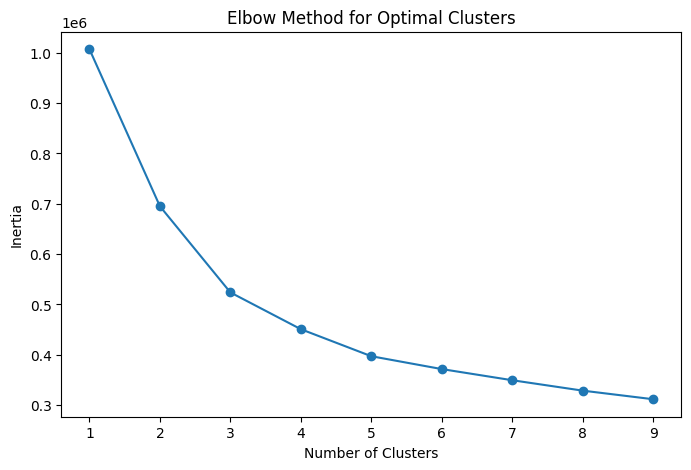

In [12]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Determine Optimal Number of Clusters for KMeans using the Elbow Method
inertia = []
range_clusters = range(1, 10)  # Test for 8 to 30 clusters

for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range_clusters, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()


In [13]:
# Apply KMeans with Optimal Clusters
optimal_clusters = 3  # Based on the elbow method
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data_rel['kmeans_cluster'] = kmeans.fit_predict(scaled_features)

# 2. Apply DBSCAN Clustering
# Define DBSCAN parameters
dbscan = DBSCAN(eps=2.3, min_samples=5)  
data_rel['dbscan_cluster'] = dbscan.fit_predict(scaled_features)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-13-fc6fc44bc869>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rel['kmeans_cluster'] = kmeans.fit_predict(scaled_features)
<ipython-input-13-fc6fc44bc869>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rel['dbscan_cluster'] = dbscan.fit_predict(scal

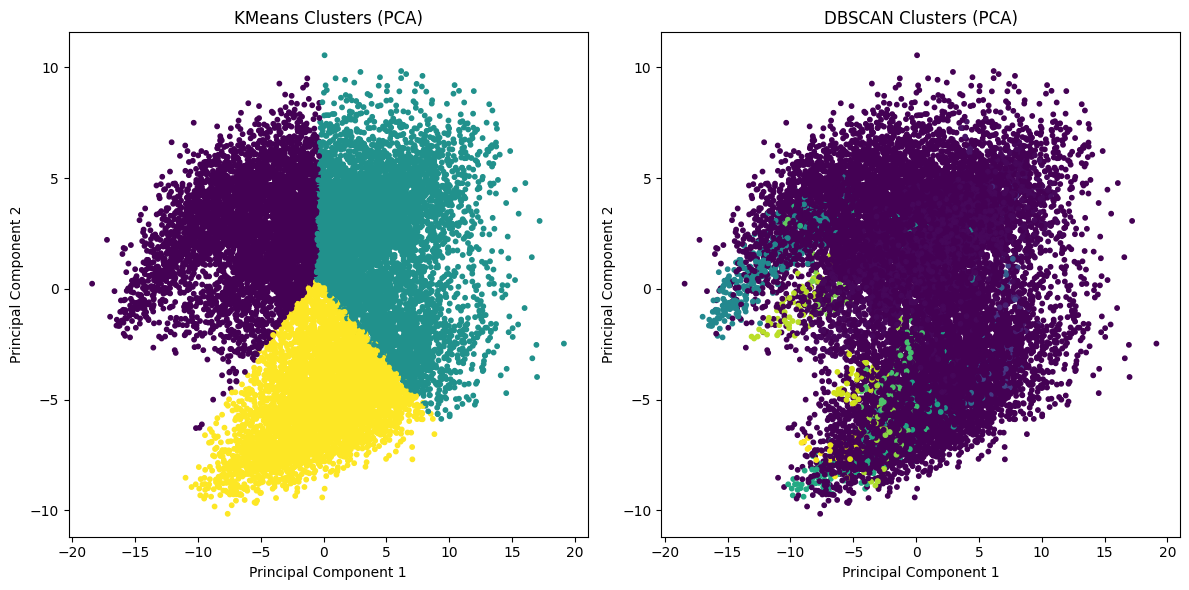

   primary_position  kmeans_cluster  dbscan_cluster
0                11               1              -1
1                13               1              -1
2                 7               1              -1
4                 7               1              -1
5                 0               1              -1


In [80]:
# Visualize Results:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Create a figure for visualization
plt.figure(figsize=(12, 6))

# KMeans Clusters
plt.subplot(1, 2, 1)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data_rel['kmeans_cluster'], cmap='viridis', s=10)
plt.title('KMeans Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# DBSCAN Clusters
plt.subplot(1, 2, 2)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data_rel['dbscan_cluster'], cmap='viridis', s=10)
plt.title('DBSCAN Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Display Cluster Results
print(data_rel[['primary_position', 'kmeans_cluster', 'dbscan_cluster']].head())


## Evaluation:

Silhouette Score - Measures how similar a data point is to its assigned cluster compared to other clusters. 
The score ranges from -1 to 1: **1: Well-clustered. 0: Overlapping clusters. -1: Incorrect clustering.**

In [82]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
silhouette_kmeans = silhouette_score(scaled_features, data_rel['kmeans_cluster'])
silhouette_dbscan = silhouette_score(scaled_features, data_rel['dbscan_cluster'])

print(f"Silhouette Score (KMeans): {silhouette_kmeans:.2f}")
print(f"Silhouette Score (DBSCAN): {silhouette_dbscan:.2f}")

Silhouette Score (KMeans): 0.28
Silhouette Score (DBSCAN): -0.53


Davies-Bouldin Index - Measures the average similarity ratio of clusters. A lower value indicates better clustering.

In [83]:
from sklearn.metrics import davies_bouldin_score

# Calculate Davies-Bouldin Index:
db_index_kmeans = davies_bouldin_score(scaled_features, data_rel['kmeans_cluster'])
db_index_dbscan = davies_bouldin_score(scaled_features, data_rel['dbscan_cluster'])

print(f"Davies-Bouldin Index (KMeans): {db_index_kmeans:.2f}")
print(f"Davies-Bouldin Index (DBSCAN): {db_index_dbscan:.2f}")


Davies-Bouldin Index (KMeans): 1.23
Davies-Bouldin Index (DBSCAN): 1.73


Within-Cluster Sum of Squares (WSS or Inertia) - Measures the compactness of clusters (used in KMeans). Lower inertia implies better clustering.

In [84]:
# Already computed as part of the elbow method
print(f"Inertia (KMeans): {kmeans.inertia_}")

Inertia (KMeans): 512260.264946221


# Part 2:

Use that 15% labels for testing and setting metrics:

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

data2 = pd.read_csv("/kaggle/input/fifa-20-complete-player-dataset/players_20.csv")
data2 = data2[~data2['team_position'].isin(['GK', None])]

# Step 1: Map positions to broader categories
position_map = {
'RW':'ST', 'LW':'ST', 'CAM':'ST', 'ST':'ST', 
'RM':'ST', 'LM':'ST', 'CF':'ST', 'LS':'ST',
'RES':'ST', 'RAM':'ST', 'RS':'ST', 'RF':'ST',
'LF':'ST', 'LAM':'ST',
'RCM':'B', 'LCB':'B', 'RCB':'B', 'LCM':'B', 'CB':'B',
'CDM':'MD', 'LDM':'MD', 'LB':'MD', 'RB':'MD',
'RDM':'MD', 'CM':'MD', 'RWB':'MD', 'LWB':'MD'}

data_rel['mapped_position'] = data2['team_position'].map(position_map)
data_rel = data_rel.dropna(subset=['mapped_position'])

# Step 2: Split the data (15% stratified by the mapped_position)
train_data, test_data = train_test_split(
    data_rel, 
    test_size=0.15, 
    stratify=data_rel['mapped_position'], 
    random_state=4
)

# Step 3: Use the labels for evaluation
# Extract the true labels for the test set
true_labels = test_data['mapped_position']

# Compare the clusters with the true labels
kmeans_ari = adjusted_rand_score(true_labels, test_data['kmeans_cluster'])
kmeans_nmi = normalized_mutual_info_score(true_labels, test_data['kmeans_cluster'])

dbscan_ari = adjusted_rand_score(true_labels, test_data['dbscan_cluster'])
dbscan_nmi = normalized_mutual_info_score(true_labels, test_data['dbscan_cluster'])

# Step 4: Display evaluation metrics
print(f"KMeans ARI: {kmeans_ari:.4f}, NMI: {kmeans_nmi:.4f}")
print(f"DBSCAN ARI: {dbscan_ari:.4f}, NMI: {dbscan_nmi:.4f}")


KMeans ARI: 0.1090, NMI: 0.1657
DBSCAN ARI: 0.0223, NMI: 0.0661


<ipython-input-23-92c9d1faf915>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rel['mapped_position'] = data2['team_position'].map(position_map)
